# SVM SHAP Explainability

Mirrors `random_forest_shap_explainability_fixed.ipynb`, adapted for SVM.

SVM (RBF kernel) is not a tree model, so `shap.TreeExplainer` does not apply.
This notebook uses `shap.KernelExplainer` instead, which is model-agnostic:
it treats the fitted pipeline's `predict_proba` as a black box and estimates
Shapley values by perturbing features against a background distribution.
This is exact in spirit but approximate in practice, and much more
expensive to compute than TreeExplainer -- runtime is controlled below via
`KMEANS_BACKGROUND_SIZE`, `EXPLAIN_SAMPLE_SIZE`, and `NSAMPLES`.

Install SHAP first if this cell raises an error:
```bash
pip install shap
```
or with the project virtual environment:
```bash
.venv/bin/pip install shap
```

## 1. Imports

In [1]:
import json
import pathlib
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import shap
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "SHAP is not installed. Install it with `pip install shap` or `.venv/bin/pip install shap`, then rerun this notebook."
    ) from exc

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")
shap.initjs()

## 2. Redefine `SentinelMedianImputer`

`svm_final_model.joblib` is a pickled `sklearn.Pipeline` whose first step is
a custom transformer class, `SentinelMedianImputer` (defined in
`svm_nested_cv_optimization.ipynb`). Unpickling requires this exact class to
be importable in the current namespace -- it is redefined here, unchanged,
purely so `joblib.load` can resolve it. The pipeline itself (imputation +
scaling + SVC) does the actual work; nothing here is re-fit.

In [2]:
class SentinelMedianImputer(BaseEstimator, TransformerMixin):
    """Replace sentinel values with training medians and append missing indicators."""

    def __init__(self, feature_names=None, sentinel_columns=None, sentinel_value=-1):
        self.feature_names = feature_names
        self.sentinel_columns = sentinel_columns
        self.sentinel_value = sentinel_value

    def fit(self, X, y=None):
        X_arr = np.asarray(X, dtype=float)
        self.feature_names_ = list(self.feature_names) if self.feature_names is not None else [
            f"feature_{idx}" for idx in range(X_arr.shape[1])
        ]
        self.sentinel_columns_ = list(self.sentinel_columns or [])
        self.sentinel_indices_ = [self.feature_names_.index(col) for col in self.sentinel_columns_]

        self.medians_ = {}
        for col, idx in zip(self.sentinel_columns_, self.sentinel_indices_):
            values = X_arr[:, idx]
            valid_values = values[values != self.sentinel_value]
            self.medians_[idx] = float(np.median(valid_values)) if len(valid_values) else 0.0
        return self

    def transform(self, X):
        X_arr = np.asarray(X, dtype=float).copy()
        indicators = []
        for idx in self.sentinel_indices_:
            missing_mask = X_arr[:, idx] == self.sentinel_value
            indicators.append(missing_mask.astype(float))
            X_arr[missing_mask, idx] = self.medians_[idx]

        if indicators:
            return np.hstack([X_arr, np.column_stack(indicators)])
        return X_arr

    def get_feature_names_out(self, input_features=None):
        base_names = list(self.feature_names_)
        missing_names = [f"{col}_missing" for col in self.sentinel_columns_]
        return np.array(base_names + missing_names, dtype=object)

## 3. Locate Repository and Load Artifacts

In [3]:
def find_repo_root():
    start_path = pathlib.Path(__file__).resolve().parent if "__file__" in globals() else pathlib.Path.cwd().resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "dataset" / "outputs" / "prediction.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing dataset/outputs/prediction.csv")


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "dataset" / "outputs" / "prediction.csv"
RESULTS_PATH = REPO_ROOT / "json-parameters" / "svm" / "svm_best_optimization_params.json"
MODEL_PATH = REPO_ROOT / "models_training" / "svm" / "svm_final_model.joblib"

with open(RESULTS_PATH, "r") as f:
    svm_results = json.load(f)

model_artifact = joblib.load(MODEL_PATH)
svm_model = model_artifact["model"]
onehot_encoder = model_artifact.get("onehot_encoder")
raw_feature_names = model_artifact["raw_feature_names"]
numeric_feature_names = model_artifact["numeric_feature_names"]
categorical_feature_names = model_artifact.get("categorical_feature_names", [])
encoded_feature_names = model_artifact["encoded_feature_names"]
sentinel_impute_columns = model_artifact["sentinel_impute_columns"]
label_encoder = model_artifact["label_encoder"]

print("Repo root:", REPO_ROOT)
print("Model path:", MODEL_PATH)
print("Results path:", RESULTS_PATH)
print("Raw features:", len(raw_feature_names), raw_feature_names)
print("Classes:", list(label_encoder.classes_))
print("SVM holdout macro F1 (from training run):", svm_results.get("final_holdout_metrics", {}).get("macro_f1"))
print("SVM pipeline:")
print(svm_model)

Repo root: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project
Model path: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/models_training/svm/svm_final_model.joblib
Results path: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/svm/svm_best_optimization_params.json
Raw features: 12 ['grid', 'qualifying_position', 'driver_std_position_prev', 'constructor_std_position_prev', 'driver_avg_position_last3', 'driver_podium_rate_last10', 'driver_points_avg_last3', 'constructor_avg_position_last3', 'driver_avg_position_at_circuit', 'teammate_h2h_avg_position_delta', 'driver_dnf_rate_historical', 'points_gap_to_leader']
Classes: ['no_points', 'podium', 'points']
SVM holdout macro F1 (from training run): 0.6818
SVM pipeline:
Pipeline(steps=[('sentinel',
                 SentinelMedianImputer(feature_names=['grid',
                                                      'qualifying_position',
                                    

## 4. Rebuild Train/Development and Holdout Feature Matrices

Same chronological split as training: 2021-2024 = train/development
(used only to build the KernelExplainer background), 2025 = holdout (the
set actually explained). `svm_model` is the **full pipeline**
(sentinel imputation -> RobustScaler -> SVC), so it is fed the 12 raw
features directly -- there is no separate manual imputation/scaling step
here, unlike the trashed `models_training/trash/svm_shap.ipynb` attempt.

In [4]:
df = pd.read_csv(DATA_PATH).sort_values(["year", "round"]).reset_index(drop=True)

holdout_split = svm_results["holdout_split"]
holdout_years = holdout_split["holdout_test_years"]
exclude_years = holdout_split.get("excluded_years", [])
target_col = "target"

holdout_mask = df["year"].isin(holdout_years)
train_dev_mask = ~(holdout_mask | df["year"].isin(exclude_years))

df_train_dev = df.loc[train_dev_mask].reset_index(drop=True)
df_holdout = df.loc[holdout_mask].reset_index(drop=True)

X_train_dev = df_train_dev[raw_feature_names].copy()
X_holdout = df_holdout[raw_feature_names].copy()

y_holdout = label_encoder.transform(df_holdout[target_col])
holdout_pred = svm_model.predict(X_holdout)
holdout_proba = svm_model.predict_proba(X_holdout)

print("Holdout years:", holdout_years)
print("Train/development rows:", len(df_train_dev))
print("Holdout rows:", len(df_holdout))
print("Feature matrix shape:", X_holdout.shape)
print("Recomputed holdout macro F1:", round(f1_score(y_holdout, holdout_pred, average="macro"), 4))

print("Classification report:")
print(classification_report(y_holdout, holdout_pred, target_names=label_encoder.classes_, digits=4))

display(pd.DataFrame(
    confusion_matrix(y_holdout, holdout_pred),
    index=[f"true_{name}" for name in label_encoder.classes_],
    columns=[f"pred_{name}" for name in label_encoder.classes_],
))

Holdout years: [2025]
Train/development rows: 1799
Holdout rows: 479
Feature matrix shape: (479, 12)
Recomputed holdout macro F1: 0.6818
Classification report:
              precision    recall  f1-score   support

   no_points     0.7490    0.7490    0.7490       239
      podium     0.6941    0.8194    0.7516        72
      points     0.5677    0.5238    0.5449       168

    accuracy                         0.6806       479
   macro avg     0.6703    0.6974    0.6818       479
weighted avg     0.6772    0.6806    0.6778       479



,pred_no_points,pred_podium,pred_points
true_no_points,179,5,55
true_podium,1,59,12
true_points,59,21,88


## 5. Build KernelExplainer Background and Compute SHAP Values

`KernelExplainer` cost scales roughly with
`background_size x n_explained x nsamples`, so both the background and the
explained set are summarized/subsampled rather than using the full
train/development and holdout sets. `shap.kmeans` summarizes the
background into `KMEANS_BACKGROUND_SIZE` weighted centroids (SHAP's
standard recipe for KernelExplainer background data). Increase these
constants for a more precise (but slower) run.

In [5]:
KMEANS_BACKGROUND_SIZE = 40   # background summary size for KernelExplainer
EXPLAIN_SAMPLE_SIZE = 150     # number of holdout rows to explain (None = all 479, much slower)
NSAMPLES = 200                # SHAP coalition samples per explained row
RANDOM_STATE = 42

background = shap.kmeans(X_train_dev.values, KMEANS_BACKGROUND_SIZE)

if EXPLAIN_SAMPLE_SIZE is None or EXPLAIN_SAMPLE_SIZE >= len(X_holdout):
    X_explain = X_holdout.copy()
    df_explain = df_holdout.copy()
else:
    X_explain = X_holdout.sample(EXPLAIN_SAMPLE_SIZE, random_state=RANDOM_STATE)
    df_explain = df_holdout.loc[X_explain.index].copy()
X_explain = X_explain.reset_index(drop=True)
df_explain = df_explain.reset_index(drop=True)

explainer = shap.KernelExplainer(svm_model.predict_proba, background)
raw_shap_values = explainer.shap_values(X_explain.values, nsamples=NSAMPLES)
expected_value = explainer.expected_value

print("Background size (kmeans centroids):", KMEANS_BACKGROUND_SIZE)
print("Explained rows:", len(X_explain))
print("SHAP raw type:", type(raw_shap_values))
print("Expected value:", expected_value)

  0%|          | 0/150 [00:00<?, ?it/s]

Background size (kmeans centroids): 40
Explained rows: 150
SHAP raw type: <class 'numpy.ndarray'>
Expected value: [0.50127699 0.11360988 0.38511313]


## 6. Normalize SHAP Output for Multi-Class SVM

Identical helper to the Random Forest notebook -- different SHAP versions
return multi-class output differently (list-of-arrays vs. a single 3D
array), so this normalizes to one dict keyed by class name.

In [6]:
def normalize_multiclass_shap_values(raw_values, class_names):
    if isinstance(raw_values, list):
        return {class_name: np.asarray(raw_values[idx]) for idx, class_name in enumerate(class_names)}

    values = np.asarray(raw_values)
    if values.ndim == 3:
        if values.shape[2] == len(class_names):
            return {class_name: values[:, :, idx] for idx, class_name in enumerate(class_names)}
        if values.shape[0] == len(class_names):
            return {class_name: values[idx, :, :] for idx, class_name in enumerate(class_names)}

    if values.ndim == 2 and len(class_names) == 2:
        return {class_names[1]: values}

    raise ValueError(f"Unsupported SHAP value shape: {values.shape}")


class_names = list(label_encoder.classes_)
shap_by_class = normalize_multiclass_shap_values(raw_shap_values, class_names)

for class_name, values in shap_by_class.items():
    print(class_name, values.shape)

no_points (150, 12)
podium (150, 12)
points (150, 12)


## 7. Global SHAP Importance

Aggregates absolute SHAP values across all explained rows and all classes.
Answers: *Which of the 12 features influence the SVM's predictions the
most overall?*

,feature,mean_abs_shap_no_points,mean_abs_shap_podium,mean_abs_shap_points,mean_abs_shap_all_classes
0,qualifying_position,0.16370,0.08112,0.10110,0.11531
1,grid,0.00666,0.03635,0.04464,0.02922
2,constructor_std_position_prev,0.04083,0.01817,0.02690,0.02864
3,constructor_avg_position_last3,0.03318,0.02404,0.01995,0.02572
4,driver_std_position_prev,0.01807,0.02465,0.01397,0.01890
5,teammate_h2h_avg_position_delta,0.02281,0.01202,0.01611,0.01698
6,driver_podium_rate_last10,0.02462,0.01064,0.01500,0.01675
7,driver_avg_position_at_circuit,0.02223,0.00411,0.01932,0.01522
8,driver_avg_position_last3,0.00720,0.01543,0.02044,0.01436
9,driver_dnf_rate_historical,0.00518,0.01449,0.01552,0.01173


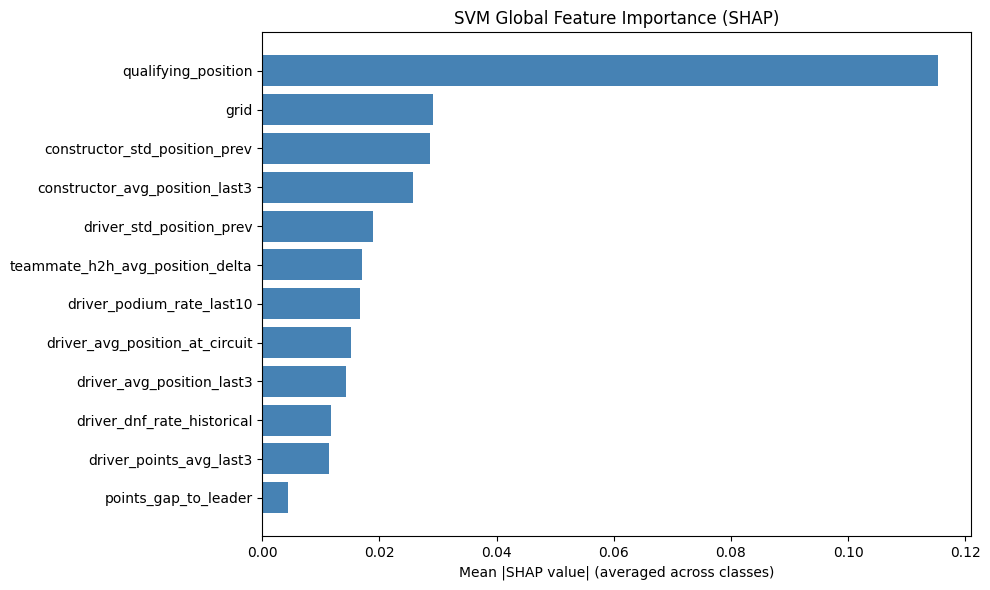

In [7]:
global_importance = pd.DataFrame({"feature": raw_feature_names})

for class_name, values in shap_by_class.items():
    global_importance[f"mean_abs_shap_{class_name}"] = np.abs(values).mean(axis=0)

global_importance["mean_abs_shap_all_classes"] = global_importance[
    [c for c in global_importance.columns if c.startswith("mean_abs_shap_") and c != "mean_abs_shap_all_classes"]
].mean(axis=1)
global_importance = global_importance.sort_values("mean_abs_shap_all_classes", ascending=False).reset_index(drop=True)

display(global_importance.round(5))

plt.figure(figsize=(10, 6))
plt.barh(global_importance["feature"][::-1], global_importance["mean_abs_shap_all_classes"][::-1], color="steelblue")
plt.xlabel("Mean |SHAP value| (averaged across classes)")
plt.title("SVM Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

## 8. Class-Specific SHAP Importance

Answers: *Which features push the SVM toward each class?* As with the RF
notebook, inspect `points` carefully -- it is the weakest class.

Top features for class: podium


,feature,mean_abs_shap
1,qualifying_position,0.08112
0,grid,0.03635
2,driver_std_position_prev,0.02465
7,constructor_avg_position_last3,0.02404
3,constructor_std_position_prev,0.01817
4,driver_avg_position_last3,0.01543
10,driver_dnf_rate_historical,0.01449
9,teammate_h2h_avg_position_delta,0.01202


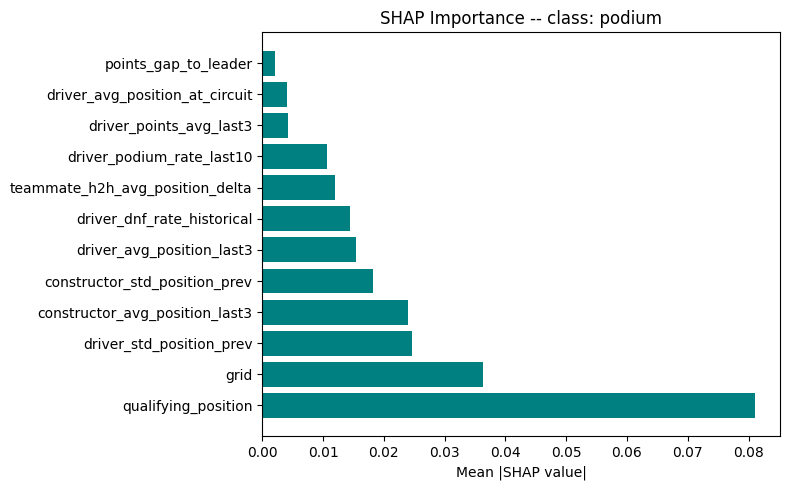

Top features for class: points


,feature,mean_abs_shap
1,qualifying_position,0.10110
0,grid,0.04464
3,constructor_std_position_prev,0.02690
4,driver_avg_position_last3,0.02044
7,constructor_avg_position_last3,0.01995
8,driver_avg_position_at_circuit,0.01932
9,teammate_h2h_avg_position_delta,0.01611
10,driver_dnf_rate_historical,0.01552


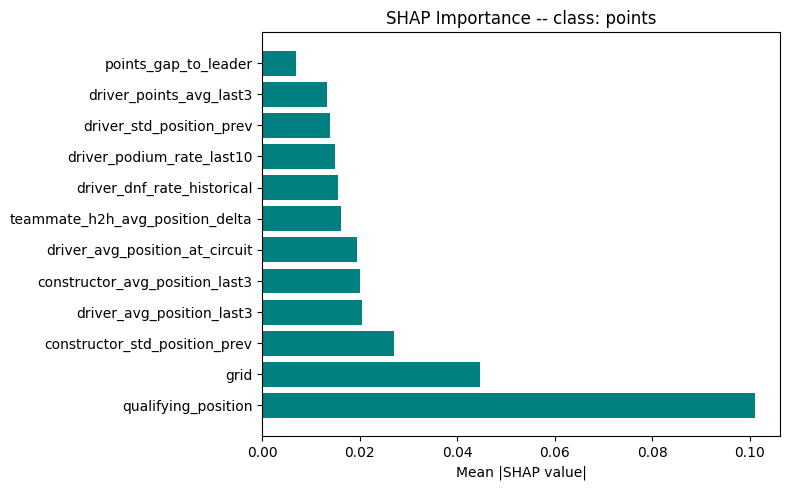

Top features for class: no_points


,feature,mean_abs_shap
1,qualifying_position,0.16370
3,constructor_std_position_prev,0.04083
7,constructor_avg_position_last3,0.03318
5,driver_podium_rate_last10,0.02462
9,teammate_h2h_avg_position_delta,0.02281
8,driver_avg_position_at_circuit,0.02223
2,driver_std_position_prev,0.01807
6,driver_points_avg_last3,0.01643


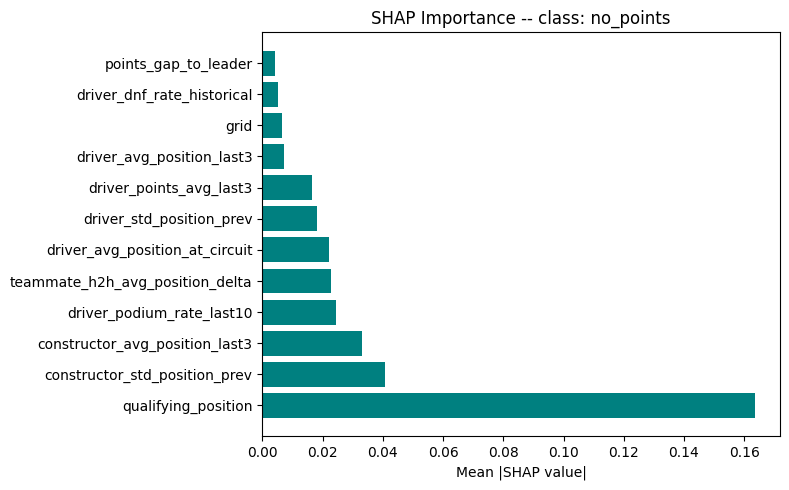

In [8]:
for class_name in ["podium", "points", "no_points"]:
    if class_name not in shap_by_class:
        continue

    class_importance = pd.DataFrame({
        "feature": raw_feature_names,
        "mean_abs_shap": np.abs(shap_by_class[class_name]).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    print(f"Top features for class: {class_name}")
    display(class_importance.head(8).round(5))

    plt.figure(figsize=(8, 5))
    plt.barh(class_importance["feature"][::-1].head(12)[::-1], class_importance["mean_abs_shap"][::-1].head(12)[::-1], color="teal")
    plt.title(f"SHAP Importance -- class: {class_name}")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

## 9. SHAP Beeswarm / Summary Plots

Shows both feature importance and direction: x-axis is SHAP value impact,
color is feature value, each dot is one explained row. One beeswarm per
class.

SHAP beeswarm for class: podium


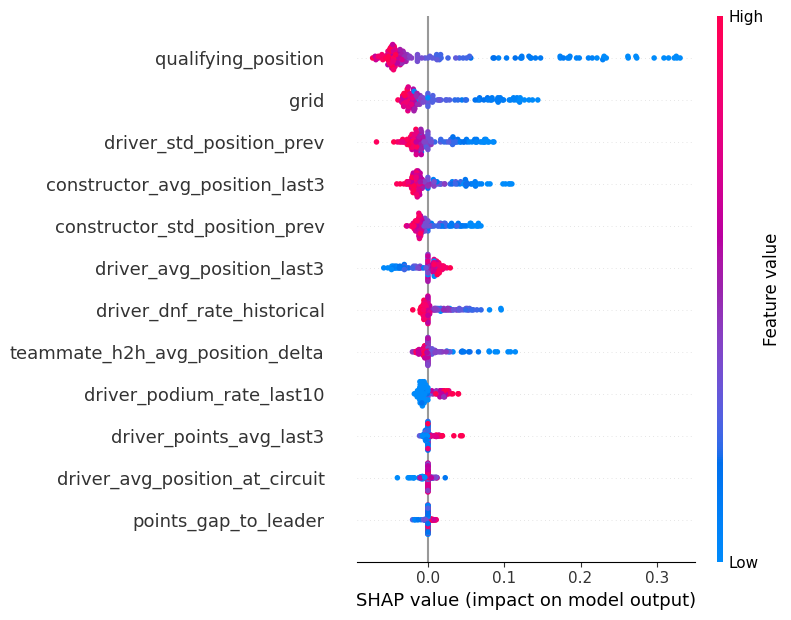

SHAP beeswarm for class: points


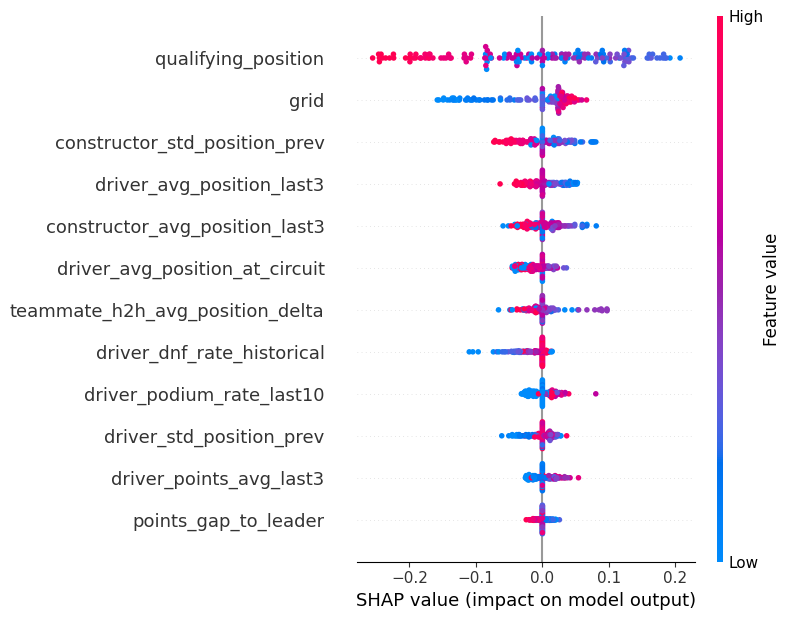

SHAP beeswarm for class: no_points


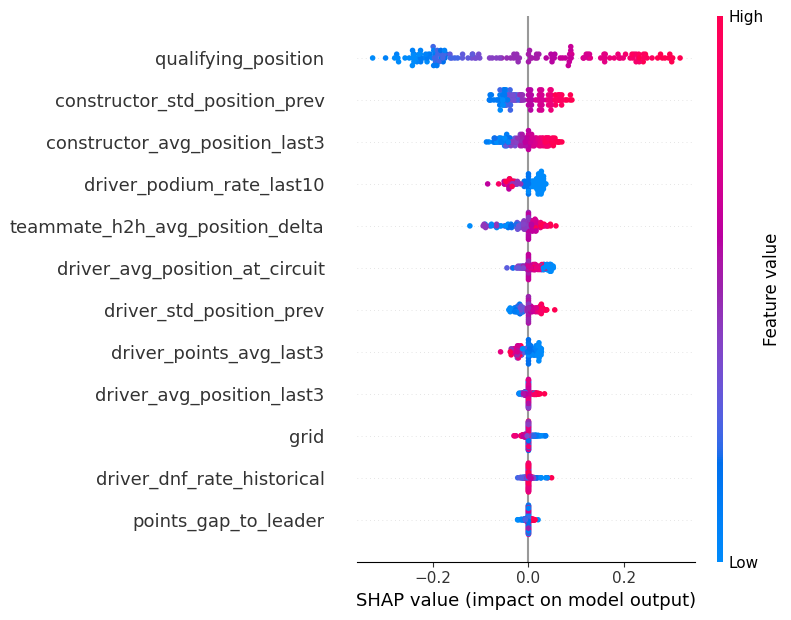

In [9]:
for class_name in ["podium", "points", "no_points"]:
    if class_name not in shap_by_class:
        continue
    print(f"SHAP beeswarm for class: {class_name}")
    shap.summary_plot(
        shap_by_class[class_name],
        X_explain,
        feature_names=raw_feature_names,
        show=True,
    )

## 10. Per-Feature SHAP Dependence Plots

Visualizes the SHAP value of each top feature against its actual (raw,
pre-scaling) feature value, for the `TARGET_CLASS_FOR_DEPENDENCE` class.

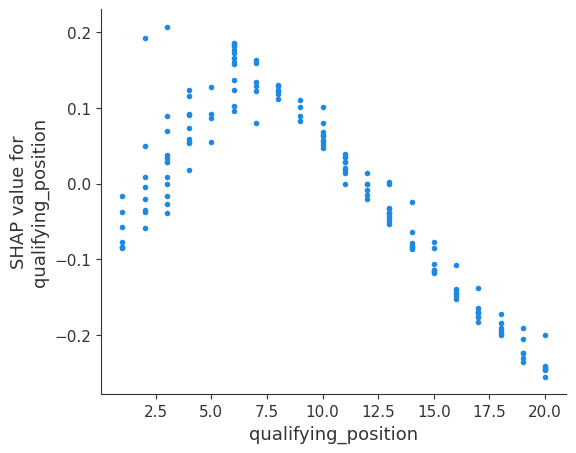

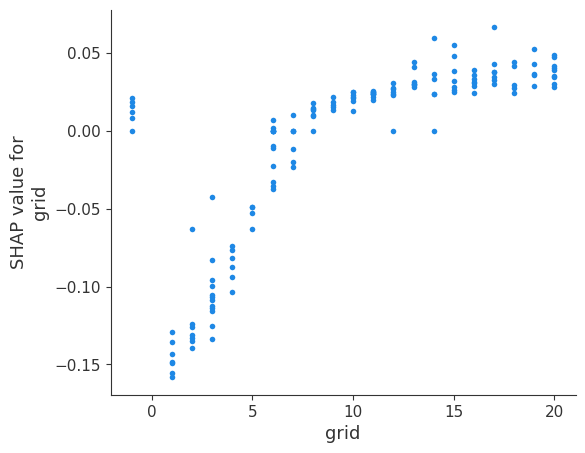

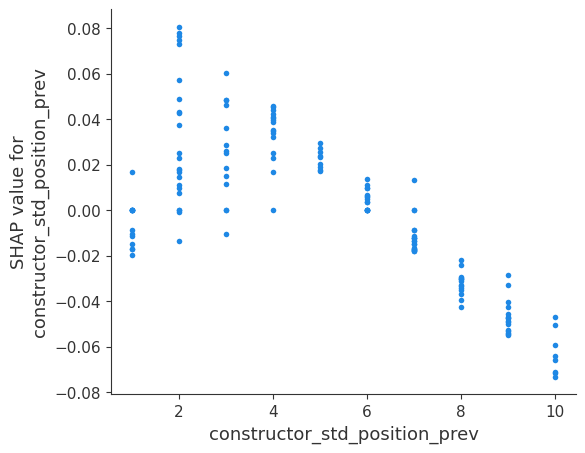

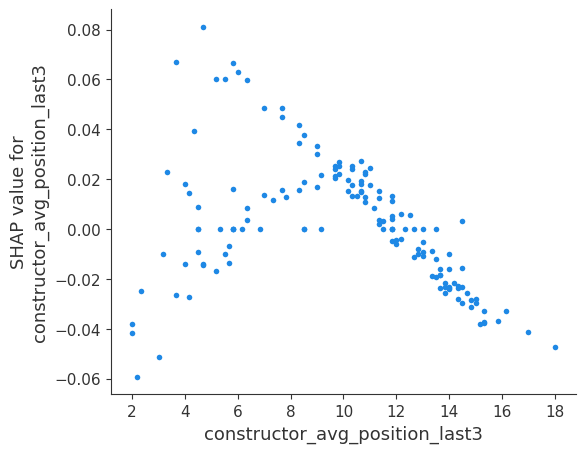

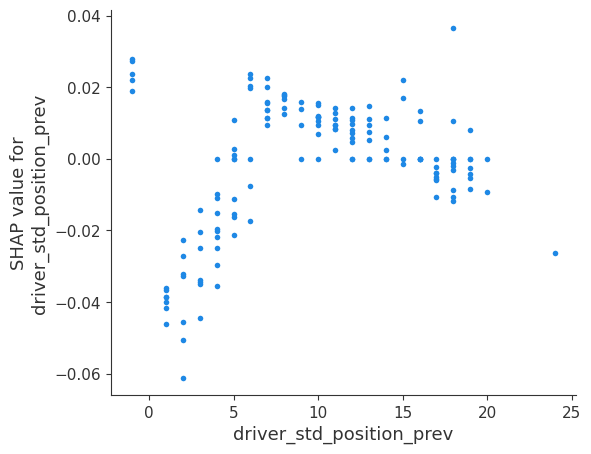

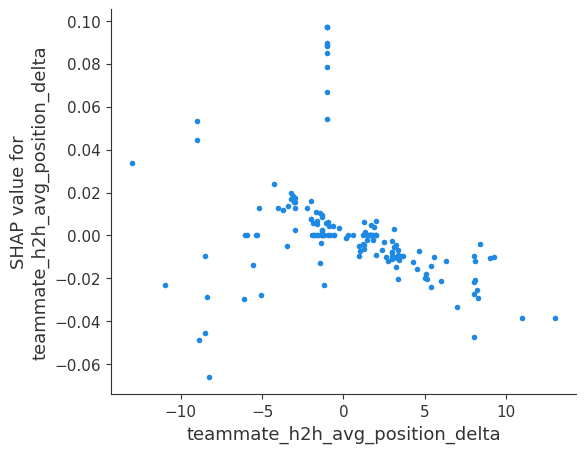

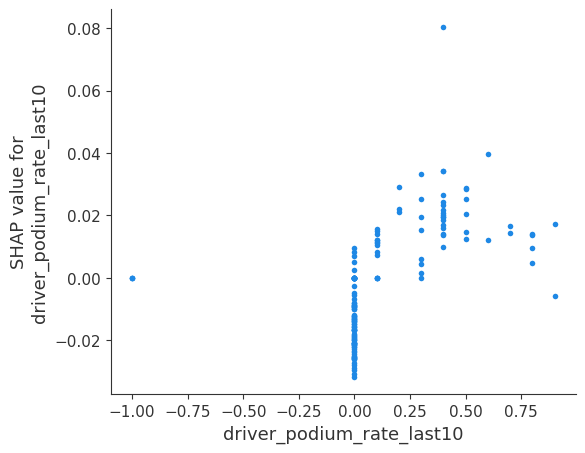

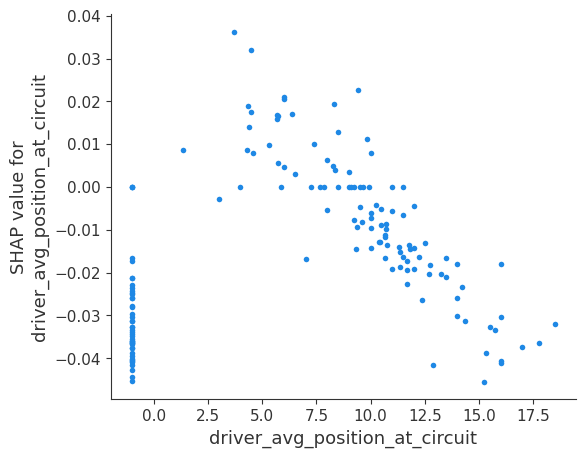

In [10]:
TOP_FEATURES_FOR_DEPENDENCE = 8
TARGET_CLASS_FOR_DEPENDENCE = "points"  # change to "podium" or "no_points" if needed

top_features = global_importance["feature"].head(TOP_FEATURES_FOR_DEPENDENCE).tolist()
class_values = shap_by_class[TARGET_CLASS_FOR_DEPENDENCE]

for feature in top_features:
    shap.dependence_plot(
        feature,
        class_values,
        X_explain,
        feature_names=raw_feature_names,
        interaction_index=None,
        show=True,
    )

## 11. Feature-Level SHAP Table

For each feature and each class, its average absolute SHAP contribution --
useful for writing the report.

In [11]:
feature_shap_table = global_importance.copy()
ordered_columns = [
    "feature",
    "mean_abs_shap_all_classes",
    *[f"mean_abs_shap_{class_name}" for class_name in class_names],
]
feature_shap_table = feature_shap_table[ordered_columns]

display(feature_shap_table.round(5))

OUT_DIR = REPO_ROOT / "models_evaluation" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / "svm_shap_feature_importance.csv"
feature_shap_table.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

,feature,mean_abs_shap_all_classes,mean_abs_shap_no_points,mean_abs_shap_podium,mean_abs_shap_points
0,qualifying_position,0.11531,0.16370,0.08112,0.10110
1,grid,0.02922,0.00666,0.03635,0.04464
2,constructor_std_position_prev,0.02864,0.04083,0.01817,0.02690
3,constructor_avg_position_last3,0.02572,0.03318,0.02404,0.01995
4,driver_std_position_prev,0.01890,0.01807,0.02465,0.01397
5,teammate_h2h_avg_position_delta,0.01698,0.02281,0.01202,0.01611
6,driver_podium_rate_last10,0.01675,0.02462,0.01064,0.01500
7,driver_avg_position_at_circuit,0.01522,0.02223,0.00411,0.01932
8,driver_avg_position_last3,0.01436,0.00720,0.01543,0.02044
9,driver_dnf_rate_historical,0.01173,0.00518,0.01449,0.01552


Saved to /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/models_evaluation/outputs/svm_shap_feature_importance.csv


## 12. Local Explanation for One Prediction

Explains a single driver-race prediction. Change `ROW_INDEX` to inspect
another explained row (indexes `df_explain`/`X_explain`, the sampled
subset -- not the full holdout).

Race ID: 1149
Year / round: 2025 5
Driver ID: 857
True label: podium
Predicted label: podium
Predicted probabilities:


,class,probability
1,podium,0.798857
2,points,0.130823
0,no_points,0.070320


,feature,feature_value,shap_value_for_predicted_class,abs_shap
1,qualifying_position,2.00000,0.27366,0.27366
0,grid,2.00000,0.11220,0.11220
7,constructor_avg_position_last3,2.00000,0.10171,0.10171
3,constructor_std_position_prev,1.00000,0.06538,0.06538
2,driver_std_position_prev,2.00000,0.06317,0.06317
10,driver_dnf_rate_historical,0.16000,0.04990,0.04990
6,driver_points_avg_last3,21.66667,0.04495,0.04495
4,driver_avg_position_last3,1.66667,-0.04106,0.04106
5,driver_podium_rate_last10,0.40000,0.01136,0.01136
8,driver_avg_position_at_circuit,9.50000,0.00396,0.00396


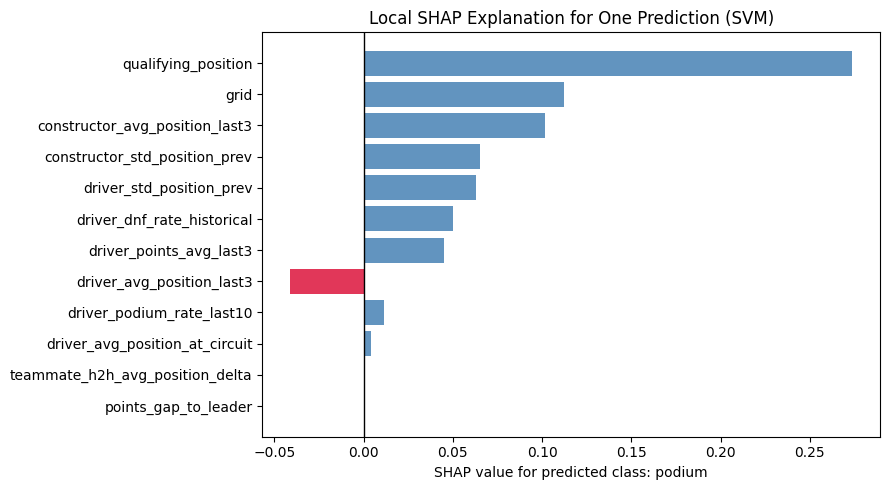

In [12]:
ROW_INDEX = 0

row = df_explain.iloc[ROW_INDEX]
x_row = X_explain.iloc[[ROW_INDEX]]
pred_encoded = svm_model.predict(x_row)[0]
pred_label = label_encoder.inverse_transform([pred_encoded])[0]
true_label = row[target_col]
proba = svm_model.predict_proba(x_row)[0]

print("Race ID:", row["raceId"])
print("Year / round:", row["year"], row["round"])
print("Driver ID:", row["driverId"])
print("True label:", true_label)
print("Predicted label:", pred_label)
print("Predicted probabilities:")
display(pd.DataFrame({"class": class_names, "probability": proba}).sort_values("probability", ascending=False))

local_class_values = shap_by_class[pred_label][ROW_INDEX]
local_explanation = pd.DataFrame({
    "feature": raw_feature_names,
    "feature_value": x_row.iloc[0].to_numpy(),
    "shap_value_for_predicted_class": local_class_values,
    "abs_shap": np.abs(local_class_values),
}).sort_values("abs_shap", ascending=False)

display(local_explanation.round(5))

plot_df = local_explanation.iloc[::-1]
colors = np.where(plot_df["shap_value_for_predicted_class"] >= 0, "steelblue", "crimson")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["feature"], plot_df["shap_value_for_predicted_class"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel(f"SHAP value for predicted class: {pred_label}")
ax.set_title("Local SHAP Explanation for One Prediction (SVM)")
plt.tight_layout()
plt.show()

## 13. Local Explanation for a Misclassified Prediction

Same as above, but for a row where the model's prediction disagreed with
the true label -- useful for discussing failure cases in the report.

Race ID: 1161
Year / round: 2025 17
Driver ID: 4
True label: no_points
Predicted label: points


,class,probability
2,points,0.498376
0,no_points,0.478716
1,podium,0.022907


,feature,feature_value,shap_value_for_predicted_class,abs_shap
1,qualifying_position,11.00000,0.03959,0.03959
0,grid,11.00000,0.02460,0.02460
7,constructor_avg_position_last3,10.66667,0.01919,0.01919
9,teammate_h2h_avg_position_delta,-3.06557,0.01639,0.01639
6,driver_points_avg_last3,4.66667,0.01282,0.01282
2,driver_std_position_prev,12.00000,0.00968,0.00968
11,points_gap_to_leader,294.00000,-0.00958,0.00958
5,driver_podium_rate_last10,0.00000,-0.00906,0.00906
8,driver_avg_position_at_circuit,8.28571,0.00485,0.00485
3,constructor_std_position_prev,6.00000,0.00477,0.00477


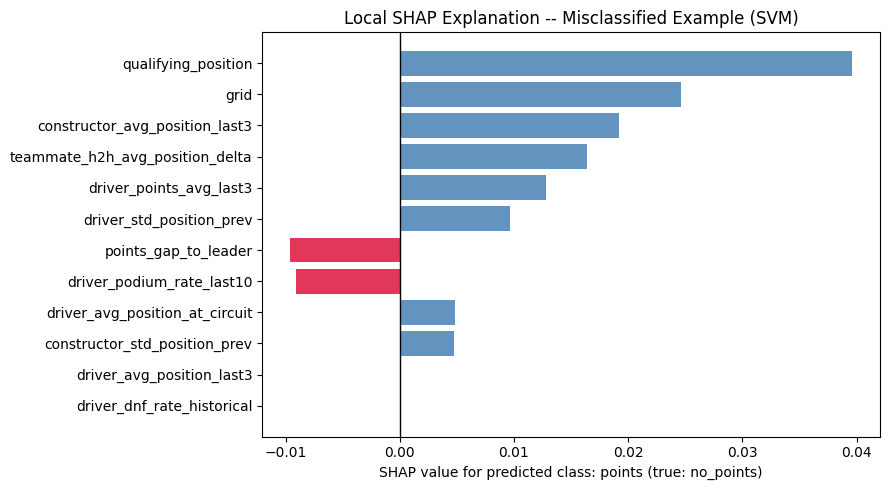

In [13]:
misclassified_mask = (df_explain[target_col] != label_encoder.inverse_transform(svm_model.predict(X_explain)))
misclassified_idx = np.flatnonzero(misclassified_mask.to_numpy())

if len(misclassified_idx) == 0:
    print("No misclassified rows in the explained sample -- increase EXPLAIN_SAMPLE_SIZE and rerun.")
else:
    ROW_INDEX_WRONG = int(misclassified_idx[0])
    row = df_explain.iloc[ROW_INDEX_WRONG]
    x_row = X_explain.iloc[[ROW_INDEX_WRONG]]
    pred_encoded = svm_model.predict(x_row)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]
    true_label = row[target_col]
    proba = svm_model.predict_proba(x_row)[0]

    print("Race ID:", row["raceId"])
    print("Year / round:", row["year"], row["round"])
    print("Driver ID:", row["driverId"])
    print("True label:", true_label)
    print("Predicted label:", pred_label)
    display(pd.DataFrame({"class": class_names, "probability": proba}).sort_values("probability", ascending=False))

    local_class_values = shap_by_class[pred_label][ROW_INDEX_WRONG]
    local_explanation = pd.DataFrame({
        "feature": raw_feature_names,
        "feature_value": x_row.iloc[0].to_numpy(),
        "shap_value_for_predicted_class": local_class_values,
        "abs_shap": np.abs(local_class_values),
    }).sort_values("abs_shap", ascending=False)

    display(local_explanation.round(5))

    plot_df = local_explanation.iloc[::-1]
    colors = np.where(plot_df["shap_value_for_predicted_class"] >= 0, "steelblue", "crimson")

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(plot_df["feature"], plot_df["shap_value_for_predicted_class"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel(f"SHAP value for predicted class: {pred_label} (true: {true_label})")
    ax.set_title("Local SHAP Explanation -- Misclassified Example (SVM)")
    plt.tight_layout()
    plt.show()

## 14. Report Notes

Suggested interpretation structure:

1. Report global top SHAP features and compare the ranking to the Random
   Forest SHAP ranking (`random_forest_shap_explainability_fixed.ipynb`) --
   do the two model families agree on what matters?
2. Discuss class-specific differences, especially `points`.
3. Include one local explanation for a correct prediction (Section 12) and
   one for an error (Section 13).
4. Mention that SHAP is computed on a sample of the 2025 holdout, so it
   explains final generalization behavior rather than training behavior.
5. Disclose the approximation: `KernelExplainer` estimates Shapley values
   via sampling (`NSAMPLES` coalitions per row) against a `kmeans`-summarized
   background (`KMEANS_BACKGROUND_SIZE` centroids), unlike `TreeExplainer`'s
   exact computation for Random Forest -- results are directionally reliable
   but noisier, and increasing `NSAMPLES`/`KMEANS_BACKGROUND_SIZE` (at the
   cost of runtime) would tighten them further.